In [1]:
import tensorflow as tf 
print(tf.__version__)

2.21.0


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
dataset=pd.read_csv('E:\python\deep_learning\Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
dataset.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [5]:
## divide the dataset into independent and dependent features 

x = dataset.drop(columns=['RowNumber', 'CustomerId', 'Surname','Exited'])   # first : means select all columns, 3:13= means that from all columns i only want from 3 index to 13 only in iloc[:,3:13]
y = dataset['Exited']


In [6]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [7]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [8]:
## feature engineering -- handling the categorical features
geography  = pd.get_dummies(x['Geography'], drop_first=True)
gender = pd.get_dummies(x['Gender'], drop_first=True)

In [9]:
geography

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,True,False


In [10]:
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [11]:
# concat the dummies data into x dataframe
x = x.drop(['Gender', 'Age'],axis=1)
x = pd.concat([x,geography, gender], axis=1)  # x means the existing columns in x , then the additional columns we want to add with the x, geography and gender

In [12]:
x = x.drop(['Geography'], axis=1)

In [13]:
x

,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,2,0.00,1,1,1,101348.88,False,False,False
1,608,1,83807.86,1,0,1,112542.58,False,True,False
2,502,8,159660.80,3,1,0,113931.57,False,False,False
3,699,1,0.00,2,0,0,93826.63,False,False,False
4,850,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...
9995,771,5,0.00,2,1,0,96270.64,False,False,True
9996,516,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,7,0.00,1,0,1,42085.58,False,False,False
9998,772,3,75075.31,2,1,0,92888.52,True,False,True


In [49]:
# split the training set and test set 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [51]:
# feature scaling 
from sklearn.preprocessing import StandardScaler  # based on the z score hypothesis testing and it also prevent data leakage conditions in test and train data
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)


In [16]:
x_train

array([[-0.09792126, -1.03635146,  1.13249447, ..., -0.56987189,
        -0.5731713 ,  0.92295821],
       [-1.12612023,  0.69700901, -1.19975467, ..., -0.56987189,
        -0.5731713 ,  0.92295821],
       [-0.62230274,  0.00366482,  1.36837909, ..., -0.56987189,
        -0.5731713 , -1.08347268],
       ...,
       [ 0.89943174,  0.00366482,  1.37307522, ..., -0.56987189,
        -0.5731713 ,  0.92295821],
       [-0.62230274,  1.39035319, -1.19975467, ..., -0.56987189,
         1.74467913, -1.08347268],
       [-0.28299708, -1.38302356,  0.52440376, ...,  1.75478035,
        -0.5731713 , -1.08347268]], shape=(7000, 10))

In [17]:
x_test

array([[-0.55032881,  1.0436811 ,  0.89172052, ...,  1.75478035,
        -0.5731713 , -1.08347268],
       [-1.31119605, -1.03635146,  0.44290036, ..., -0.56987189,
        -0.5731713 , -1.08347268],
       [ 0.57040807,  1.0436811 ,  0.32196604, ..., -0.56987189,
         1.74467913, -1.08347268],
       ...,
       [ 0.35448628, -1.03635146,  1.48039672, ..., -0.56987189,
        -0.5731713 ,  0.92295821],
       [ 0.42646021,  1.73702529,  1.27224953, ..., -0.56987189,
        -0.5731713 ,  0.92295821],
       [ 0.82745781, -0.34300727,  0.21730138, ...,  1.75478035,
        -0.5731713 , -1.08347268]], shape=(3000, 10))

In [18]:
print(x_train.shape)
print(x_test.shape)

(7000, 10)
(3000, 10)


In [22]:
# Create ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU
from tensorflow.keras.layers import Dropout

In [59]:
# initializing ANN
classifier = Sequential()

In [ ]:

#adding the input layer 
classifier.add(Dense(units=10, activation='relu'))
                     

In [62]:
#add first hidden layer 
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))  # drop the neuron to prevent overfitting 
#second hidden layer
classifier.add(Dense(units=6, activation='relu'))
classifier.add(Dropout(0.3))

In [63]:
# add output layer
classifier.add(Dense(1,activation='sigmoid'))

In [64]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [65]:
## train neural network 
classifier.compile(optimizer= opt, loss='binary_crossentropy', metrics=['accuracy'])


In [66]:
# apply early stopping = stop training when a monitored metric has stopped improving
early_stopping  = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [67]:
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000, callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7908 - loss: 0.5039 - val_accuracy: 0.7955 - val_loss: 0.4532
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7955 - loss: 0.4641 - val_accuracy: 0.7955 - val_loss: 0.4459
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7936 - loss: 0.4620 - val_accuracy: 0.7955 - val_loss: 0.4406
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7968 - loss: 0.4552 - val_accuracy: 0.7952 - val_loss: 0.4347
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7964 - loss: 0.4545 - val_accuracy: 0.7952 - val_loss: 0.4384
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7975 - loss: 0.4455 - val_accuracy: 0.7955 - val_loss: 0.4415
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8052 - loss: 0.4381 - val_accuracy: 0.8175 - val_loss: 0.4205
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8082 - loss: 0.4316 - 

In [53]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

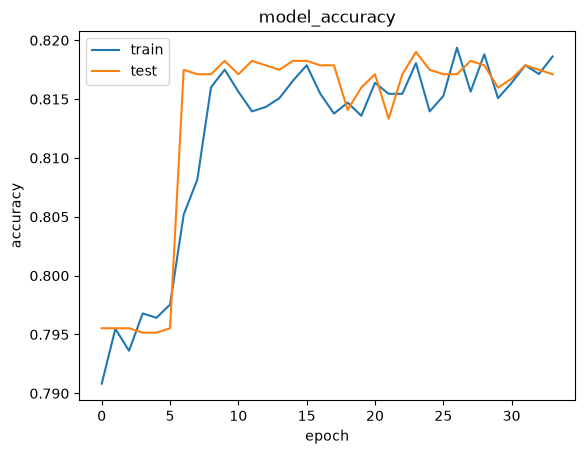

In [68]:
# summarize history for accuracy 
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model_accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [69]:
# predict the y_test 
y_pred = classifier.predict(x_test)
y_pred = (y_pred >= 0.5)   #apply the threshold at 0.5 if the value is greater and equal to 0.5 then we will predict 1 otherwise 0

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [70]:
## confusion matrix 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1543,   52],
       [ 308,   97]])

In [71]:
# calculate the accuracy 
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.82

In [72]:
# get the weights of model 
classifier.get_weights()

[array([[-2.6188961e-01, -9.0242803e-01, -3.5029924e-01,  2.0666118e-01,
          1.0889460e-02,  6.7701042e-02, -4.5008376e-01,  5.9379991e-02,
          3.2213090e-03,  7.9378664e-02],
        [-3.7450147e-01,  3.5054496e-01,  5.1746386e-01,  4.2301666e-02,
          7.0468783e-02,  3.0201465e-01, -6.6901064e-01,  2.5846479e-02,
         -5.8142930e-01, -3.1062105e-01],
        [ 6.2845558e-01, -1.9825597e+00,  5.8329529e-01, -1.8755397e+00,
          9.3481278e-01, -2.3039112e+00,  1.0594107e+00,  7.9831570e-01,
          1.2040823e+00,  1.3078097e+00],
        [ 2.6766374e+00, -3.3039269e+00,  1.8717402e+00, -3.2136316e+00,
          2.3156571e+00,  1.4895219e+00,  2.4215069e+00,  2.4659626e+00,
         -2.0842423e+00, -2.0309837e+00],
        [ 5.7773310e-01, -3.6032349e-01,  4.9555317e-01, -4.6982039e-02,
         -1.9974408e-01, -8.6833037e-02, -1.9831134e-01,  3.4006704e-02,
         -1.6912612e-01,  5.4366589e-01],
        [-1.2990043e+00, -9.7708499e-01, -4.3649414e-01, -7.